In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
csv_path = "./data/solar_flares.csv"
df = pd.read_csv(csv_path)
df # column names are good

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,H,S,X,1,2,1,1,1,1,1,0,0,0
1385,H,S,X,2,2,1,1,2,1,1,0,0,0
1386,C,S,O,1,2,1,2,2,1,1,0,0,0
1387,H,R,X,1,2,1,1,2,1,1,0,0,0


In [3]:
df.isna().sum() # no missing values

zurich_class                0
largest_spot_size           0
spot_distribution           0
activity                    0
evolution                   0
prev_24hr_flare_activity    0
historically_complex        0
became_complex_this_pass    0
area                        0
area_largest_spot           0
c_class_flares              0
m_class_flares              0
x_class_flares              0
dtype: int64

In [4]:
df.duplicated().sum() # 862 duplicates, but they are probably all separate observations

np.int64(862)

In [5]:
dupe_counts = df.groupby(list(df.columns)).size().reset_index(name="count")
dupe_counts = dupe_counts.sort_values("count", ascending=False)
dupe_counts.head(10) # top 10 duplicates are all non flare observations, supports that they are all separate observations

,zurich_class,largest_spot_size,spot_distribution,activity,evolution,prev_24hr_flare_activity,historically_complex,became_complex_this_pass,area,area_largest_spot,c_class_flares,m_class_flares,x_class_flares,count
20,B,X,O,1,3,1,1,2,1,1,0,0,0,90
499,H,S,X,1,2,1,1,2,1,1,0,0,0,44
86,C,R,O,1,3,1,1,2,1,1,0,0,0,43
14,B,X,O,1,2,1,1,2,1,1,0,0,0,38
495,H,S,X,1,2,1,1,1,1,1,0,0,0,34
507,H,S,X,1,3,1,1,1,1,1,0,0,0,25
80,C,R,O,1,2,1,1,2,1,1,0,0,0,23
503,H,S,X,1,2,1,2,1,1,1,0,0,0,23
116,C,S,O,1,3,1,1,2,1,1,0,0,0,22
253,D,R,O,1,3,1,1,2,1,1,0,0,0,21


#### Visualizations

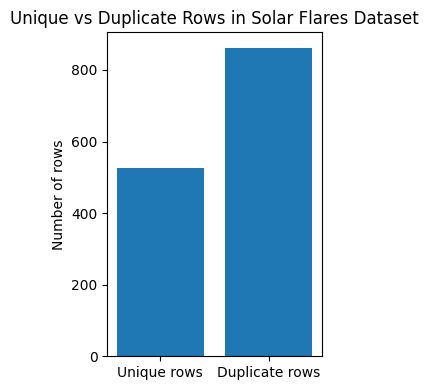

In [6]:
n_duplicates = df.duplicated().sum()
n_unique = len(df) - n_duplicates

fig, ax = plt.subplots(figsize=(3, 4))
bars = ax.bar(["Unique rows", "Duplicate rows"], [n_unique, n_duplicates])

ax.set_ylabel("Number of rows")
ax.set_title("Unique vs Duplicate Rows in Solar Flares Dataset")

plt.tight_layout()
plt.show()

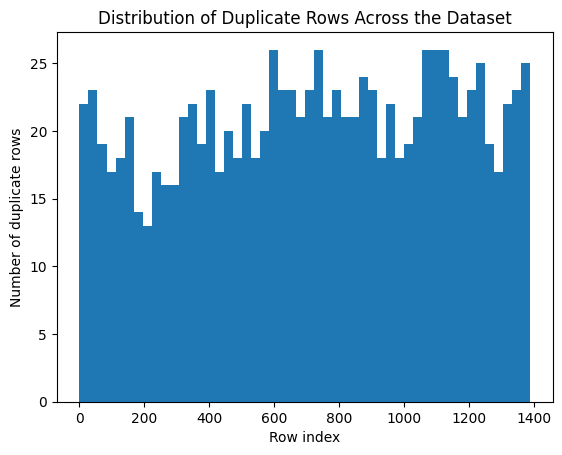

In [7]:
dup_indices = df[df.duplicated(keep=False)].index

plt.hist(dup_indices, bins=50)

plt.title("Distribution of Duplicate Rows Across the Dataset")
plt.xlabel("Row index")
plt.ylabel("Number of duplicate rows")

plt.show()

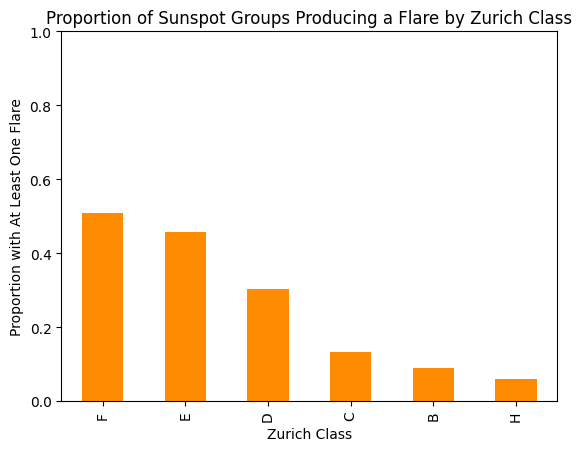

In [8]:
df["any_flare"] = (df["c_class_flares"] + df["m_class_flares"] + df["x_class_flares"]) > 0

flare_rate_by_class = df.groupby("zurich_class")["any_flare"].mean().sort_values(ascending=False)

flare_rate_by_class.plot(kind="bar", color="darkorange")
plt.title("Proportion of Sunspot Groups Producing a Flare by Zurich Class")
plt.xlabel("Zurich Class")
plt.ylabel("Proportion with At Least One Flare")
plt.ylim(0, 1)

plt.show()

#
note: can simplify these two graphs under here.. for example make all the bars the same length to show the c, m, x distributions properly

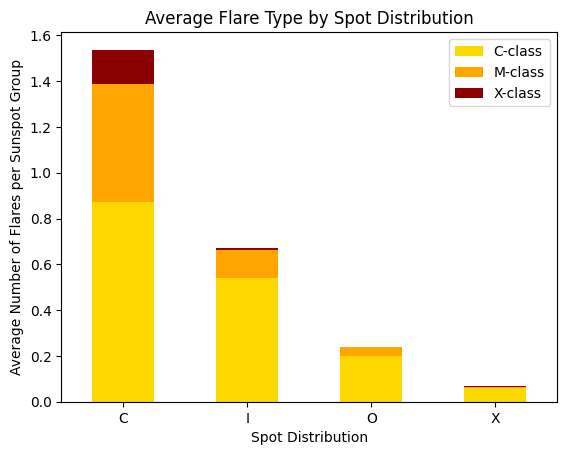

In [9]:
flare_composition = df.groupby("spot_distribution")[["c_class_flares", "m_class_flares", "x_class_flares"]].mean()
flare_composition = flare_composition.loc[flare_composition.sum(axis=1).sort_values(ascending=False).index]

flare_composition.plot(kind="bar", stacked=True, color=["gold", "orange", "darkred"])
plt.ylabel("Average Number of Flares per Sunspot Group")
plt.xlabel("Spot Distribution")
plt.title("Average Flare Type by Spot Distribution")
plt.legend(["C-class", "M-class", "X-class"])
plt.xticks(rotation=0)

plt.show()

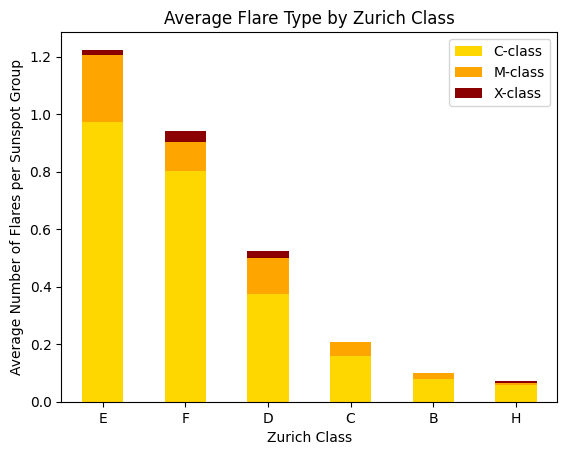

In [10]:
flare_composition = df.groupby("zurich_class")[["c_class_flares", "m_class_flares", "x_class_flares"]].mean()
flare_composition = flare_composition.loc[flare_composition.sum(axis=1).sort_values(ascending=False).index]

flare_composition.plot(kind="bar", stacked=True, color=["gold", "orange", "darkred"])
plt.ylabel("Average Number of Flares per Sunspot Group")
plt.xlabel("Zurich Class")
plt.title("Average Flare Type by Zurich Class")
plt.legend(["C-class", "M-class", "X-class"])
plt.xticks(rotation=0)

plt.show()

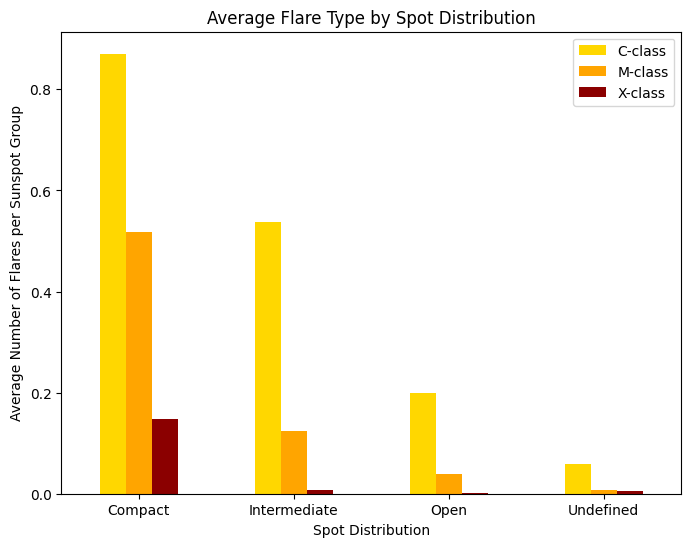

In [11]:
# lightning talk visualizations
flare_composition = df.groupby("spot_distribution")[["c_class_flares", "m_class_flares", "x_class_flares"]].mean()
flare_composition = flare_composition.loc[flare_composition.sum(axis=1).sort_values(ascending=False).index]

label_map = {"X": "Undefined", "O": "Open", "I": "Intermediate", "C": "Compact"}
flare_composition_renamed = flare_composition.rename(index=label_map)

flare_composition_renamed.plot(kind="bar", stacked=False, color=["gold", "orange", "darkred"], figsize=(8, 6))
plt.ylabel("Average Number of Flares per Sunspot Group")
plt.xlabel("Spot Distribution")
plt.title("Average Flare Type by Spot Distribution")
plt.legend(["C-class", "M-class", "X-class"])
plt.xticks(rotation=0)
plt.show()

In [12]:
# chi squared test: Is there a relationship between zurich class and flares?
contingency_table = pd.crosstab(df["zurich_class"], df["any_flare"])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2_stat}")
print(f"P-value: {p_value}") # the p-value is much smaller than 0.05, so reject the null hypothesis

Chi-squared statistic: 180.21042319444592
P-value: 4.825051965090237e-37
